# Opteo Prep: Marketing Campaign Analysis

**Author:** Raphael
**Goal:** End-to-end EDA and regression on a marketing campaign dataset, as preparation for a data science internship at Opteo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts show inline and look decent by default
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Loading the data

In [ ]:
df = pd.read_csv('data/marketing_campaign_dataset.csv')
df.head()

In [3]:
print("Shape: ", df.shape)
print("\nColumn Types: ")
df.info()

Shape:  (200000, 16)

Column Types: 
<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200000 non-null  int64  
 1   Company           200000 non-null  str    
 2   Campaign_Type     200000 non-null  str    
 3   Target_Audience   200000 non-null  str    
 4   Duration          200000 non-null  str    
 5   Channel_Used      200000 non-null  str    
 6   Conversion_Rate   200000 non-null  float64
 7   Acquisition_Cost  200000 non-null  str    
 8   ROI               200000 non-null  float64
 9   Location          200000 non-null  str    
 10  Language          200000 non-null  str    
 11  Clicks            200000 non-null  int64  
 12  Impressions       200000 non-null  int64  
 13  Engagement_Score  200000 non-null  int64  
 14  Customer_Segment  200000 non-null  str    
 15  Date              200000 non-null  str    

In [4]:
df.describe()

,Campaign_ID,Conversion_Rate,ROI,Clicks,Impressions,Engagement_Score
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,100000.500000,0.080070,5.002438,549.772030,5507.301520,5.494710
std,57735.171256,0.040602,1.734488,260.019056,2596.864286,2.872581
min,1.000000,0.010000,2.000000,100.000000,1000.000000,1.000000
25%,50000.750000,0.050000,3.500000,325.000000,3266.000000,3.000000
50%,100000.500000,0.080000,5.010000,550.000000,5517.500000,5.000000
75%,150000.250000,0.120000,6.510000,775.000000,7753.000000,8.000000
max,200000.000000,0.150000,8.000000,1000.000000,10000.000000,10.000000


### Initial observations
- 200,000 rows × 16 columns, no missing values.
- `Acquisition_Cost`, `Duration`, and `Date` are strings that need parsing.
- `Conversion_Rate` and `ROI` are already numeric — likely pre-computed.
- [Note the cardinality of each categorical: which are low-cardinality (good predictors) vs. high-cardinality]
- No `CTR` or `CPC` columns — we'll derive those.

## 2. Data cleaning

In [5]:
df.isna().sum().sort_values(ascending=False)

Campaign_ID         0
Company             0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Conversion_Rate     0
Acquisition_Cost    0
ROI                 0
Location            0
Language            0
Clicks              0
Impressions         0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64

In [6]:
df['Acquisition_Cost'] = (
    df['Acquisition_Cost']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)
df['Acquisition_Cost'].describe()

count    200000.000000
mean      12504.393040
std        4337.664545
min        5000.000000
25%        8739.750000
50%       12496.500000
75%       16264.000000
max       20000.000000
Name: Acquisition_Cost, dtype: float64

In [7]:
# Duration is likely "30 days" — extract the number
df['Duration_Days'] = df['Duration'].str.extract(r'(\d+)').astype(int)
df['Duration_Days'].value_counts().sort_index()

Duration_Days
15    49779
30    50255
45    50100
60    49866
Name: count, dtype: int64

In [8]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.day_name()
df[['Date', 'Year', 'Month', 'DayOfWeek']].head()

,Date,Year,Month,DayOfWeek
0,2021-01-01,2021,1,Friday
1,2021-01-02,2021,1,Saturday
2,2021-01-03,2021,1,Sunday
3,2021-01-04,2021,1,Monday
4,2021-01-05,2021,1,Tuesday


In [9]:
# Click-through rate
df['CTR'] = df['Clicks'] / df['Impressions']

# Cost per click
df['CPC'] = df['Acquisition_Cost'] / df['Clicks']

# Conversions (estimated from clicks × conversion rate)
df['Conversions'] = df['Clicks'] * df['Conversion_Rate']

# Cost per acquisition
df['CPA'] = df['Acquisition_Cost'] / df['Conversions']

# Cost per thousand impressions
df['CPM'] = (df['Acquisition_Cost'] / df['Impressions']) * 1000

df[['CTR', 'CPC', 'Conversions', 'CPA', 'CPM']].describe()

,CTR,CPC,Conversions,CPA,CPM
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,0.140405,32.008490,44.022898,635.329122,3193.942663
std,0.130881,26.926121,32.317026,970.140241,2698.980271
min,0.010054,5.021084,1.000000,34.217755,501.401401
25%,0.058606,15.091967,17.760000,180.484192,1508.453122
50%,0.099789,22.774008,35.760000,334.396247,2269.955677
75%,0.169699,38.599088,64.100000,692.480613,3837.796498
max,0.992024,199.960000,150.000000,19432.352941,19896.103896


In [10]:
print("Any infinities?", np.isinf(df[['CTR', 'CPC', 'CPA', 'CPM']]).sum().sum())
print("Any negatives where shouldn't be?")
print((df[['CTR', 'CPC', 'CPA', 'CPM', 'Acquisition_Cost', 'Conversions']] < 0).sum())
print("\nCTR range:", df['CTR'].min(), "to", df['CTR'].max())
print("CPC range:", df['CPC'].min(), "to", df['CPC'].max())

Any infinities? 0
Any negatives where shouldn't be?
CTR                 0
CPC                 0
CPA                 0
CPM                 0
Acquisition_Cost    0
Conversions         0
dtype: int64

CTR range: 0.010054293183189221 to 0.9920239282153539
CPC range: 5.021084337349397 to 199.96


## 3. Exploratory Data Analysis

### 3.1 Distributions of core metrics

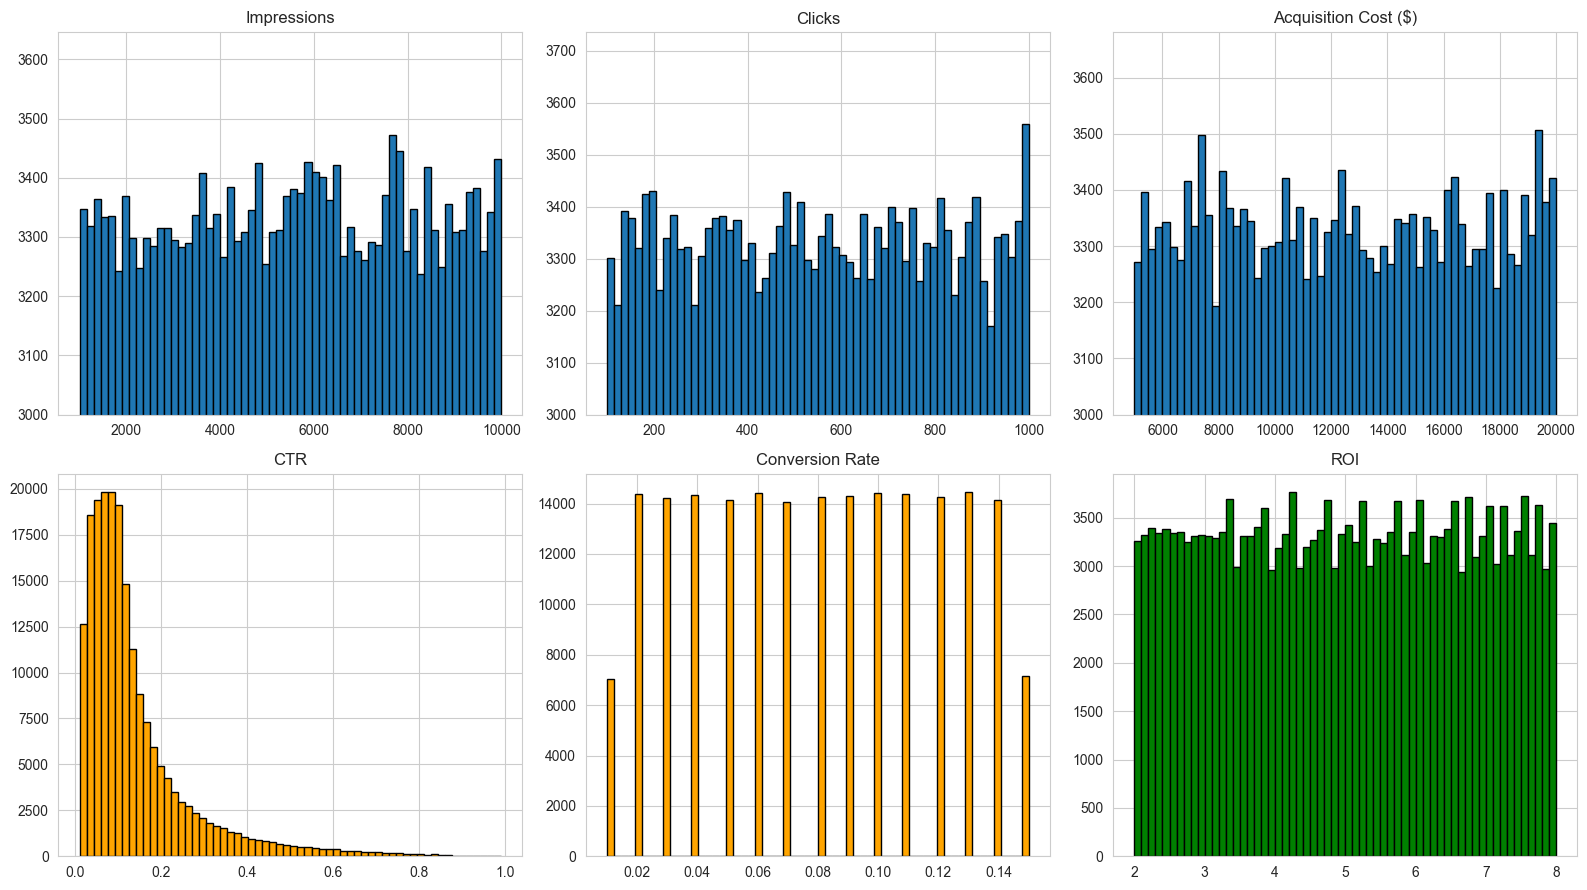

In [22]:
fig, axes = plt.subplots(2,3, figsize=(16, 9))

axes[0,0].hist(df['Impressions'], bins=60, edgecolor = 'black')
axes[0,0].set_title('Impressions')
axes[0,0].set_ylim(3000, None)

axes[0,1].hist(df['Clicks'], bins=60, edgecolor = 'black')
axes[0,1].set_title('Clicks')
axes[0,1].set_ylim(3000, None)

axes[0, 2].hist(df['Acquisition_Cost'], bins=60, edgecolor='black')
axes[0, 2].set_title('Acquisition Cost ($)')
axes[0,2].set_ylim(3000, None)

axes[1, 0].hist(df['CTR'], bins=60, edgecolor='black', color='orange')
axes[1, 0].set_title('CTR')

axes[1, 1].hist(df['Conversion_Rate'], bins=60, edgecolor='black', color='orange')
axes[1, 1].set_title('Conversion Rate')

axes[1, 2].hist(df['ROI'], bins=60, edgecolor='black', color='green')
axes[1, 2].set_title('ROI')

plt.tight_layout()
plt.show()

### 3.2 Performance by channel

In [23]:
channel_perf = df.groupby('Channel_Used').agg(
    avg_ctr=('CTR', 'mean'),
    avg_cpc=('CPC', 'mean'),
    avg_roi=('ROI', 'mean'),
    avg_conv_rate=('Conversion_Rate', 'mean'),
    total_spend=('Acquisition_Cost', 'sum'),
    n_campaigns=('Campaign_ID', 'count')
).sort_values('avg_roi', ascending=False)

channel_perf

,avg_ctr,avg_cpc,avg_roi,avg_conv_rate,total_spend,n_campaigns
Channel_Used,,,,,,
Facebook,0.140499,32.129253,5.018699,0.079992,410595258.0,32819
Website,0.140971,31.779545,5.014167,0.080183,416593500.0,33360
Google Ads,0.139190,32.309304,5.003141,0.080183,418912314.0,33438
Email,0.140543,31.881471,4.996487,0.080282,420874104.0,33599
YouTube,0.141196,31.872808,4.993754,0.079889,416778582.0,33392
Instagram,0.140037,32.080786,4.988706,0.079886,417124850.0,33392


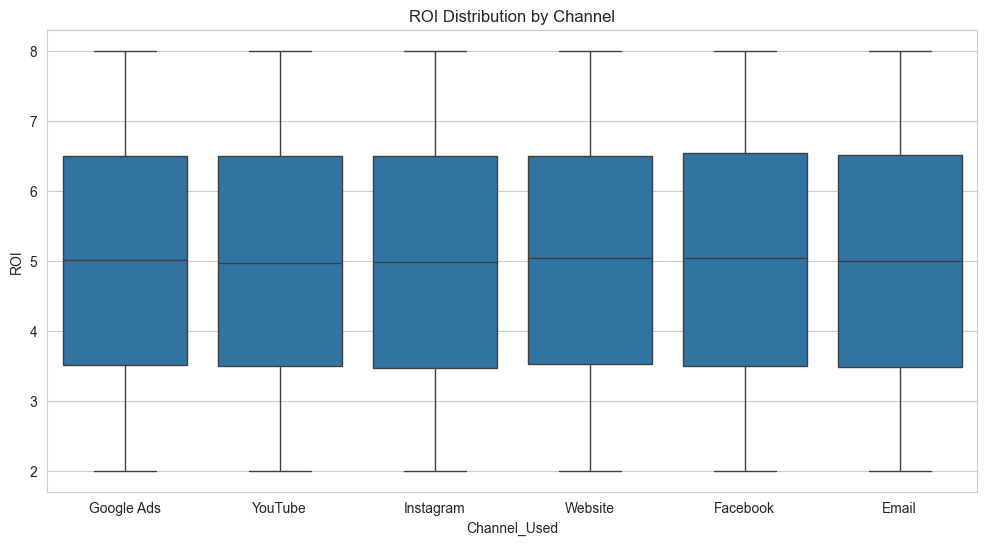

In [29]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Channel_Used', y='ROI')
plt.title('ROI Distribution by Channel')
# plt.xticks(rotation=30)
plt.show()

### 3.3 Performance by campaign type and audience


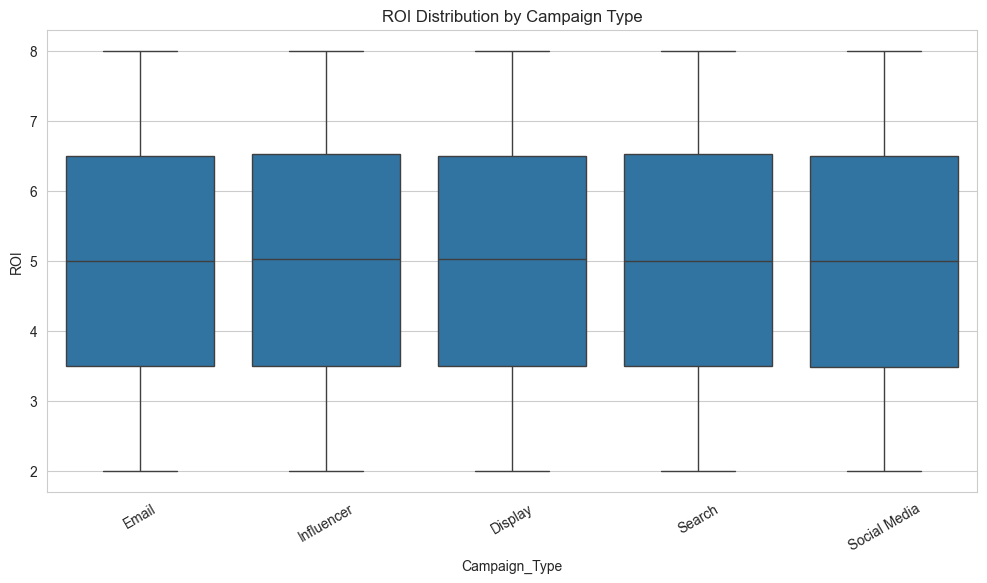

In [30]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Campaign_Type', y='ROI')
plt.title('ROI Distribution by Campaign Type')
plt.xticks(rotation=30)
plt.show()

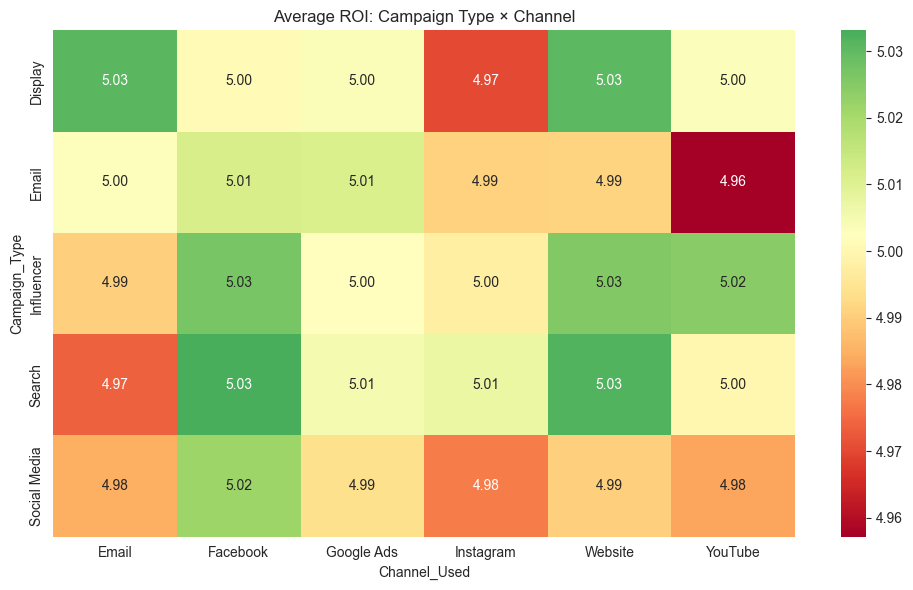

In [31]:
pivot = df.pivot_table(values='ROI', index='Campaign_Type',
                       columns='Channel_Used', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=pivot.values.mean())
plt.title('Average ROI: Campaign Type × Channel')
plt.tight_layout()
plt.show()

### 3.4 Correlations among numeric features

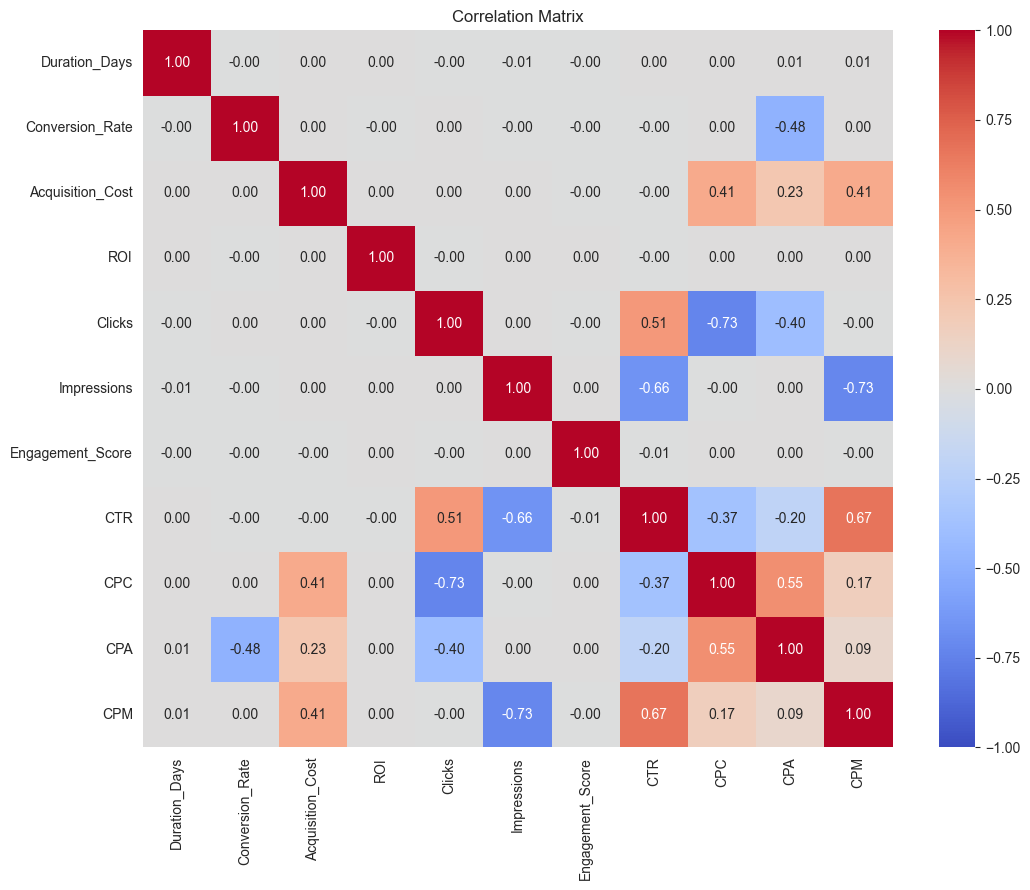

In [33]:
numeric_cols = ['Duration_Days', 'Conversion_Rate', 'Acquisition_Cost',
                'ROI', 'Clicks', 'Impressions', 'Engagement_Score',
                'CTR', 'CPC', 'CPA', 'CPM']

plt.figure(figsize=(11, 9))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### 3.5 Time trends

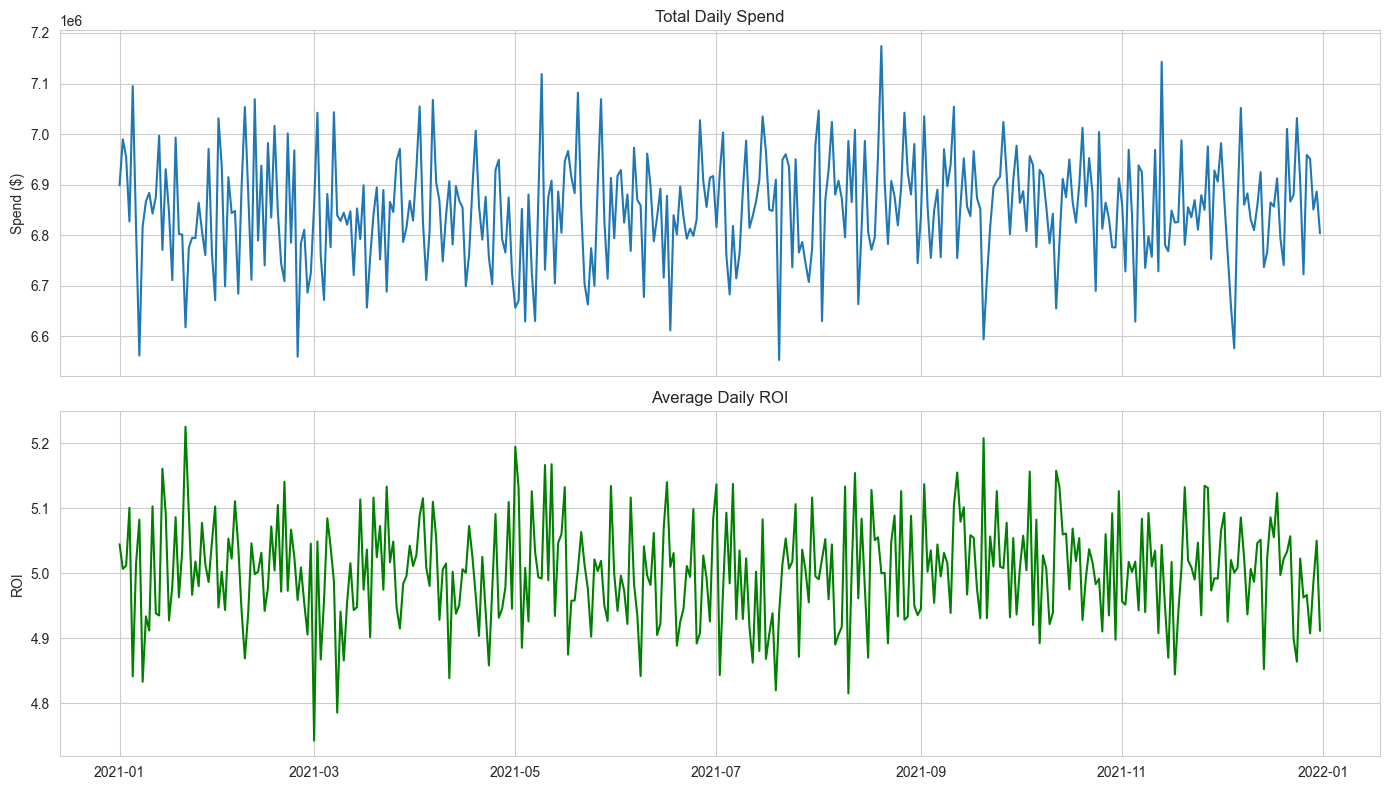

In [34]:
daily = df.groupby('Date').agg(
    total_spend=('Acquisition_Cost', 'sum'),
    avg_roi=('ROI', 'mean'),
    total_clicks=('Clicks', 'sum'),
    n_campaigns=('Campaign_ID', 'count')
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(daily['Date'], daily['total_spend'])
axes[0].set_title('Total Daily Spend')
axes[0].set_ylabel('Spend ($)')

axes[1].plot(daily['Date'], daily['avg_roi'], color='green')
axes[1].set_title('Average Daily ROI')
axes[1].set_ylabel('ROI')

plt.tight_layout()
plt.show()

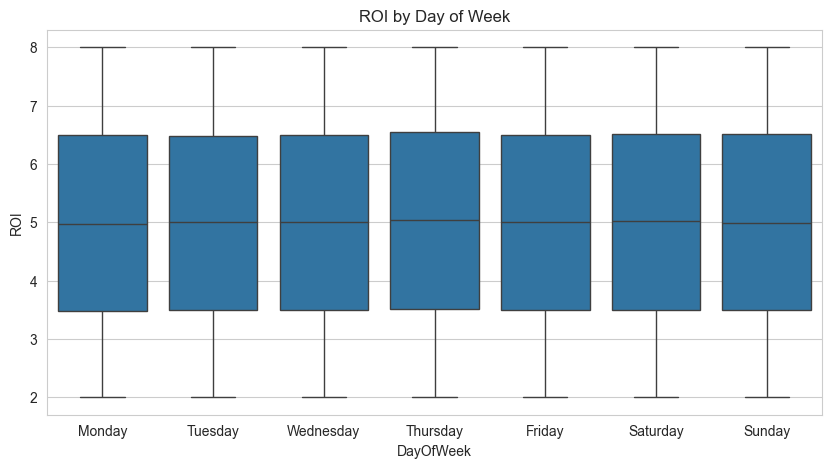

In [35]:
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
             'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='DayOfWeek', y='ROI', order=dow_order)
plt.title('ROI by Day of Week')
plt.show()

### 3.6 Cost vs. clicks (a relationship we'll model tomorrow)

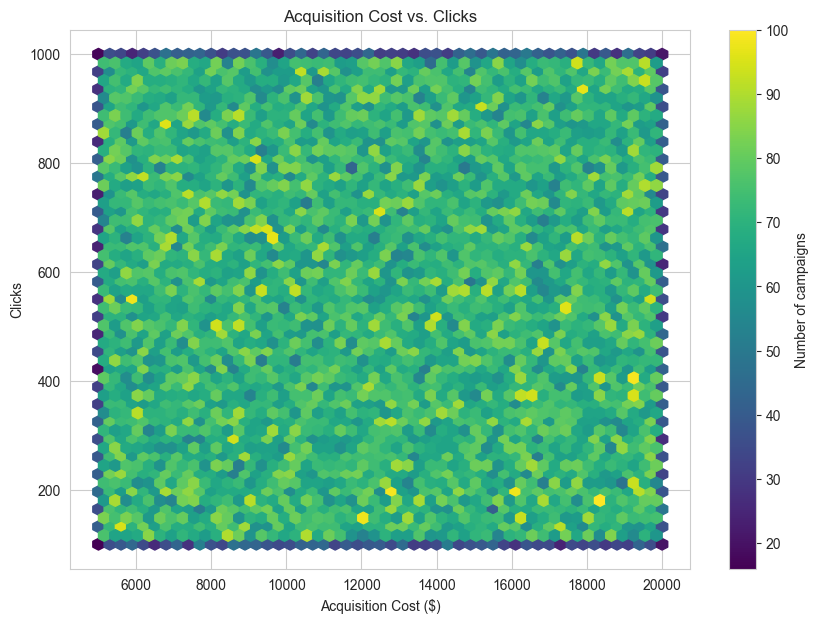

In [36]:
plt.figure(figsize=(10, 7))
plt.hexbin(df['Acquisition_Cost'], df['Clicks'], gridsize=50, cmap='viridis', mincnt=1)
plt.colorbar(label='Number of campaigns')
plt.xlabel('Acquisition Cost ($)')
plt.ylabel('Clicks')
plt.title('Acquisition Cost vs. Clicks')
plt.show()

**Data overview:**
- 200,000 campaigns, no missing values
- Cleaned Acquisition_Cost ($-string → float), parsed Duration and Date
- Derived 5 new metrics: CTR, CPC, Conversions, CPA, CPM

**Key findings so far:**
- Completely Random!!!! 

## 4. Predictive modeling

**Caveat:** Day 1 EDA revealed that this dataset appears to be synthetic random data, distributions are roughly uniform, correlations are near zero, and there are no visible relationships between features.

We expect regression to find little to no signal. The goal of this section is therefore not to *find* a predictive model, but to demonstrate the **methodology**: how to set up regression correctly, interpret diagnostics, and recognize when a model has failed.

In [39]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

### 4.1 Defining target and predictors

In [40]:
# Target
y = df['ROI']

# Numeric predictors
numeric_features = ['Duration_Days', 'Acquisition_Cost', 'Clicks',
                    'Impressions', 'Engagement_Score', 'Conversion_Rate']

# Low-cardinality categoricals to one-hot encode
categorical_features = ['Campaign_Type', 'Channel_Used', 'Target_Audience',
                        'Customer_Segment', 'Location']

# One-hot encode categoricals (drop_first avoids the dummy variable trap)
X_cat = pd.get_dummies(df[categorical_features], drop_first=True)

# Combine
X = pd.concat([df[numeric_features], X_cat], axis=1)

# Make sure everything is numeric and finite
X = X.astype(float)
print("Feature matrix shape:", X.shape)
X.head()

Feature matrix shape: (200000, 27)


,Duration_Days,Acquisition_Cost,Clicks,Impressions,Engagement_Score,Conversion_Rate,Campaign_Type_Email,Campaign_Type_Influencer,Campaign_Type_Search,Campaign_Type_Social Media,...,Target_Audience_Women 25-34,Target_Audience_Women 35-44,Customer_Segment_Foodies,Customer_Segment_Health & Wellness,Customer_Segment_Outdoor Adventurers,Customer_Segment_Tech Enthusiasts,Location_Houston,Location_Los Angeles,Location_Miami,Location_New York
0,30.0,16174.0,506.0,1922.0,6.0,0.04,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,60.0,11566.0,116.0,7523.0,7.0,0.12,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,30.0,10200.0,584.0,7698.0,1.0,0.07,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,60.0,12724.0,217.0,1820.0,7.0,0.11,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,15.0,16452.0,379.0,4201.0,3.0,0.05,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [41]:
X_with_const = sm.add_constant(X)  # adds the intercept term
model = sm.OLS(y, X_with_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    ROI   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.408
Date:                Sat, 16 May 2026   Prob (F-statistic):             0.0776
Time:                        21:03:03   Log-Likelihood:            -3.9391e+05
No. Observations:              200000   AIC:                         7.879e+05
Df Residuals:                  199972   BIC:                         7.882e+05
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


In [42]:
pvals = model.pvalues.drop('const')
n_sig = (pvals < 0.05).sum()
n_total = len(pvals)
print(f"{n_sig} of {n_total} predictors significant at α=0.05")
print(f"At α=0.05, we expect {0.05 * n_total:.1f} false positives by chance alone")
print("\nSignificant predictors:")
print(pvals[pvals < 0.05].sort_values())

1 of 27 predictors significant at α=0.05
At α=0.05, we expect 1.4 false positives by chance alone

Significant predictors:
Acquisition_Cost    0.03966
dtype: float64


### 4.3 Regression diagnostics

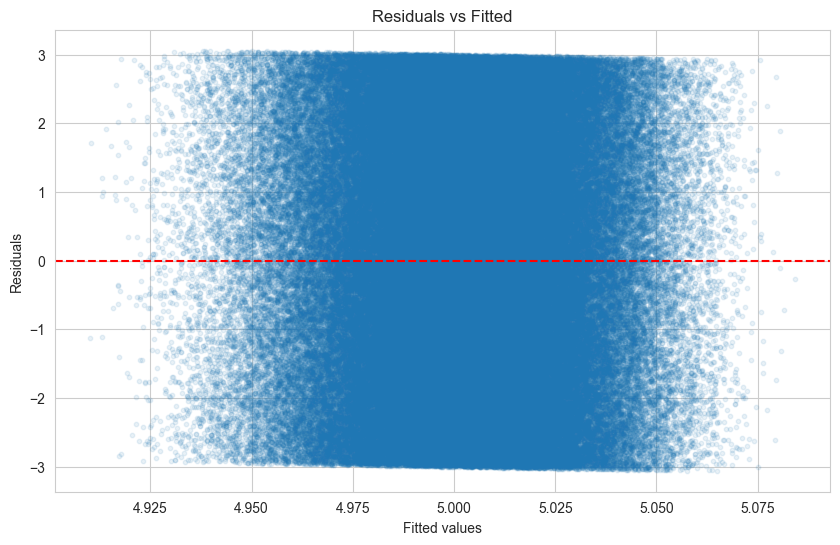

In [43]:
fitted = model.fittedvalues
resid = model.resid

plt.figure(figsize=(10, 6))
plt.scatter(fitted, resid, alpha=0.1, s=10)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.show()

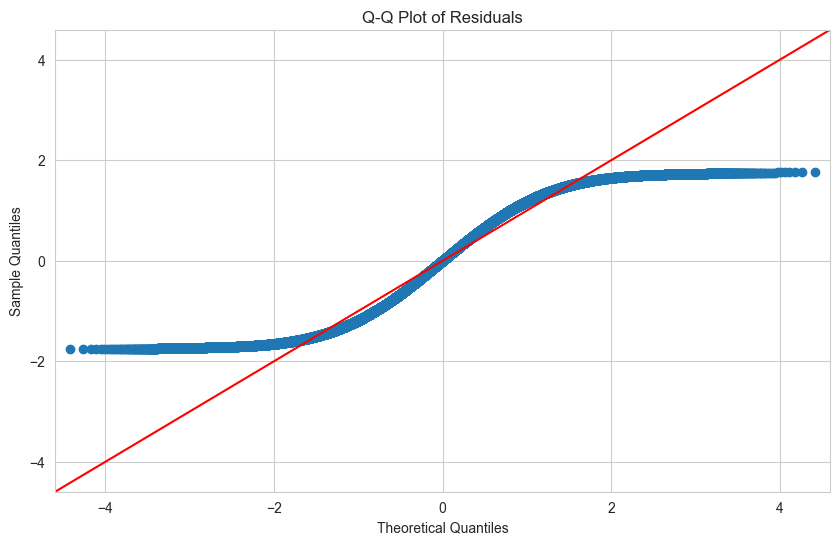

In [52]:
fig = sm.qqplot(resid, line='45', fit=True)
plt.title('Q-Q Plot of Residuals')
plt.show()

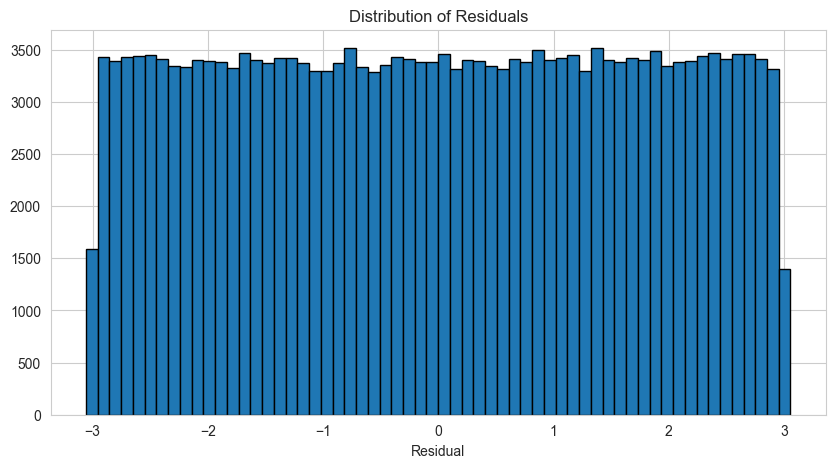

In [47]:
plt.figure(figsize=(10, 5))
plt.hist(resid, bins=60, edgecolor='black')
plt.title('Distribution of Residuals')
plt.xlabel('Residual')
plt.show()

In [48]:
# Compute VIF for numeric predictors only (categoricals less informative here)
X_num = X[numeric_features]

vif_data = pd.DataFrame()
vif_data['feature'] = X_num.columns
vif_data['VIF'] = [variance_inflation_factor(X_num.values, i)
                   for i in range(X_num.shape[1])]
vif_data.sort_values('VIF', ascending=False)

,feature,VIF
1,Acquisition_Cost,6.809900
0,Duration_Days,5.022733
3,Impressions,4.689884
2,Clicks,4.676620
5,Conversion_Rate,4.270978
4,Engagement_Score,4.100128


### 4.4 Alternative specification: log-transformed cost

In [49]:
X2 = X.copy()
X2['log_Acquisition_Cost'] = np.log1p(X2['Acquisition_Cost'])
X2 = X2.drop(columns=['Acquisition_Cost'])

model2 = sm.OLS(y, sm.add_constant(X2)).fit()

print(f"Original R²: {model.rsquared:.6f}")
print(f"Log-cost R²: {model2.rsquared:.6f}")
print(f"\nOriginal AIC: {model.aic:.1f}")
print(f"Log-cost AIC: {model2.aic:.1f}")

Original R²: 0.000190
Log-cost R²: 0.000184

Original AIC: 787877.4
Log-cost AIC: 787878.7
